# ECG Digitalization: Exploratory Data Analysis

This notebook explores the ECG digitization dataset and the relationship between the original ECG signals and their image representations. The analysis looks at the dataset structure, signal characteristics, ECG images, image degradation, and the structure of the test data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
import warnings
from scipy import signal
from collections import Counter

!pip install --upgrade plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define paths
DATA_PATH = Path('/kaggle/input/physionet-ecg-image-digitization')
TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH = DATA_PATH / 'test'

print("✅ Libraries imported successfully!")
print(f"📁 Data path: {DATA_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
✅ Libraries imported successfully!
📁 Data path: /kaggle/input/physionet-ecg-image-digitization


The first step is to load the training and test metadata. This gives a quick overview of the available samples, the columns in each file, and the information that will be used in the later analysis.

In [ ]:
# Load training and test metadata
train_df = pd.read_csv(DATA_PATH / 'train.csv')
test_df = pd.read_csv(DATA_PATH / 'test.csv')

print(f"📊 Training samples: {len(train_df):,}")
print(f"📊 Test samples: {len(test_df['id'].unique()):,} unique IDs")
print(f"📊 Total test predictions needed: {len(test_df):,} (12 leads per ID)")

# Display first few rows
print("\n" + "="*80)
print("TRAINING DATA SAMPLE")
print("="*80)
display(train_df.head(10))

print("\n" + "="*80)
print("TEST DATA SAMPLE")
print("="*80)
display(test_df.head(15))

📊 Training samples: 977
📊 Test samples: 2 unique IDs
📊 Total test predictions needed: 24 (12 leads per ID)

TRAINING DATA SAMPLE


,id,fs,sig_len
0,7663343,500,5000
1,10140238,1000,10000
2,11842146,1000,10000
3,19030958,250,2500
4,19585145,512,5120
5,31175200,250,2500
6,31294838,512,5120
7,32650710,250,2500
8,35187032,500,5000
9,36494663,1025,10250



TEST DATA SAMPLE


,id,lead,fs,number_of_rows
0,1053922973,I,1000,2500
1,1053922973,II,1000,10000
2,1053922973,III,1000,2500
3,1053922973,aVR,1000,2500
4,1053922973,aVL,1000,2500
5,1053922973,aVF,1000,2500
6,1053922973,V1,1000,2500
7,1053922973,V2,1000,2500
8,1053922973,V3,1000,2500
9,1053922973,V4,1000,2500


The dataset contains recordings with different sampling frequencies. Here, I check how the samples are distributed across these frequencies, since the sampling rate directly affects the number of points available in each ECG signal.

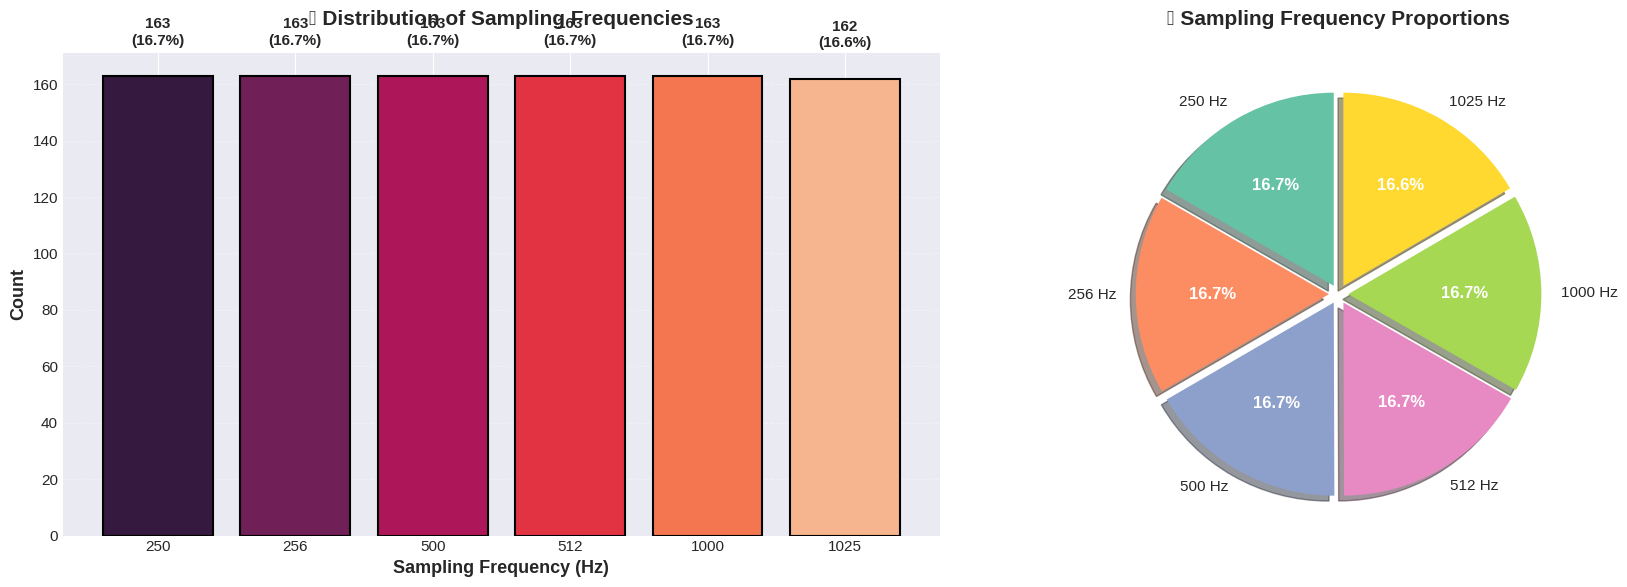


SAMPLING FREQUENCY STATISTICS
   250 Hz: 163 samples (16.68%)
   256 Hz: 163 samples (16.68%)
   500 Hz: 163 samples (16.68%)
   512 Hz: 163 samples (16.68%)
  1000 Hz: 163 samples (16.68%)
  1025 Hz: 162 samples (16.58%)


In [ ]:
# Analyze sampling frequency distribution
fs_counts = train_df['fs'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
colors = sns.color_palette("rocket", len(fs_counts))
axes[0].bar(fs_counts.index.astype(str), fs_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Sampling Frequency (Hz)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=13, fontweight='bold')
axes[0].set_title('📊 Distribution of Sampling Frequencies', fontsize=15, fontweight='bold', pad=20)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (fs, count) in enumerate(zip(fs_counts.index, fs_counts.values)):
    axes[0].text(i, count + 10, f'{count}\n({count/len(train_df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
colors_pie = sns.color_palette("Set2", len(fs_counts))
wedges, texts, autotexts = axes[1].pie(fs_counts.values, labels=[f'{fs} Hz' for fs in fs_counts.index],
                                        autopct='%1.1f%%', startangle=90, colors=colors_pie,
                                        explode=[0.05]*len(fs_counts), shadow=True)
axes[1].set_title('📊 Sampling Frequency Proportions', fontsize=15, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SAMPLING FREQUENCY STATISTICS")
print("="*60)
for fs, count in fs_counts.items():
    print(f"  {fs:4d} Hz: {count:3d} samples ({count/len(train_df)*100:5.2f}%)")
print("="*60)

Next, I compare the signal lengths for different sampling frequencies and calculate the corresponding recording duration. This helps confirm how the stored signal length changes with the sampling rate.


SIGNAL LENGTH STATISTICS BY SAMPLING FREQUENCY


,min,max,mean,std,count
fs,,,,,
250,2500,2500,2500.0,0.0,163
256,2560,2560,2560.0,0.0,163
500,5000,5000,5000.0,0.0,163
512,5120,5120,5120.0,0.0,163
1000,10000,10000,10000.0,0.0,163
1025,10250,10250,10250.0,0.0,162



✅ All signal lengths match fs × 10 seconds: True


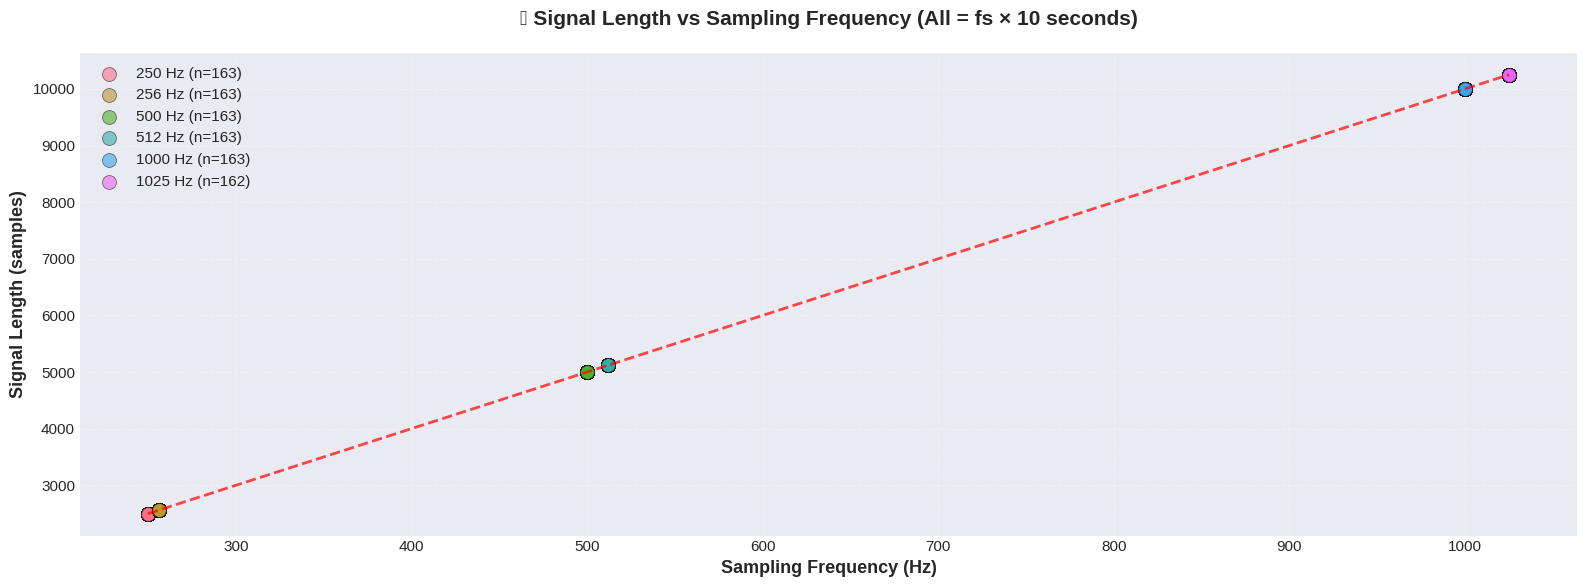

In [ ]:
# Analyze signal lengths
sig_len_stats = train_df.groupby('fs')['sig_len'].agg(['min', 'max', 'mean', 'std', 'count'])

print("\n" + "="*80)
print("SIGNAL LENGTH STATISTICS BY SAMPLING FREQUENCY")
print("="*80)
display(sig_len_stats)

# Verify the relationship: sig_len = fs * 10 seconds
train_df['calculated_sig_len'] = train_df['fs'] * 10
train_df['sig_len_match'] = train_df['sig_len'] == train_df['calculated_sig_len']

print(f"\n✅ All signal lengths match fs × 10 seconds: {train_df['sig_len_match'].all()}")

# Visualize
fig, ax = plt.subplots(figsize=(16, 6))

for fs in sorted(train_df['fs'].unique()):
    subset = train_df[train_df['fs'] == fs]
    ax.scatter([fs]*len(subset), subset['sig_len'], alpha=0.6, s=100,
               label=f'{fs} Hz (n={len(subset)})', edgecolors='black', linewidth=0.5)

ax.set_xlabel('Sampling Frequency (Hz)', fontsize=13, fontweight='bold')
ax.set_ylabel('Signal Length (samples)', fontsize=13, fontweight='bold')
ax.set_title('📏 Signal Length vs Sampling Frequency (All = fs × 10 seconds)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')

# Add reference line
fs_range = sorted(train_df['fs'].unique())
sig_len_range = [fs * 10 for fs in fs_range]
ax.plot(fs_range, sig_len_range, 'r--', linewidth=2, label='Theoretical (fs × 10)', alpha=0.7)

plt.tight_layout()
plt.show()

---
# 📊 2. Understanding ECG Structure

## What is a 12-Lead ECG?

An ECG (Electrocardiogram) measures the electrical activity of the heart from 12 different perspectives:

**Limb Leads (6 leads):**
- **I, II, III**: Bipolar limb leads (measure voltage between two electrodes)
- **aVR, aVL, aVF**: Augmented unipolar limb leads

**Chest Leads (6 leads):**
- **V1-V6**: Precordial leads placed across the chest

## Standard Layout:
- **Top 3 rows**: Each contains 4 leads (2.5 seconds each)
- **Bottom row**: Lead II "rhythm strip" (10 seconds - full cardiac rhythm)

## ECG Waveform Components:
- **P wave**: Atrial depolarization
- **QRS complex**: Ventricular depolarization (the heartbeat)
- **T wave**: Ventricular repolarization
- **Grid**: Time (horizontal) vs Voltage (vertical)
  - Standard: 1mm = 0.04s (time), 1mm = 0.1mV (voltage)

To understand the data more clearly, I load one complete ECG sample along with its metadata. This gives access to the actual time-series values behind the ECG image.

In [ ]:
# Load a sample ECG for detailed analysis
sample_id = str(train_df['id'].iloc[0])
sample_fs = train_df[train_df['id'] == int(sample_id)]['fs'].values[0]
sample_sig_len = train_df[train_df['id'] == int(sample_id)]['sig_len'].values[0]

# Load time series data
ecg_data = pd.read_csv(TRAIN_PATH / sample_id / f'{sample_id}.csv')

print(f"📋 Sample ECG ID: {sample_id}")
print(f"📊 Sampling Frequency: {sample_fs} Hz")
print(f"📏 Signal Length: {sample_sig_len} samples ({sample_sig_len/sample_fs:.1f} seconds)")
print(f"📌 ECG Data Shape: {ecg_data.shape}")
print(f"\n🔍 Available Leads: {list(ecg_data.columns)}")

display(ecg_data.head())

📋 Sample ECG ID: 7663343
📊 Sampling Frequency: 500 Hz
📏 Signal Length: 5000 samples (10.0 seconds)
📌 ECG Data Shape: (5000, 12)

🔍 Available Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,0.04,0.1,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.04,0.1,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.04,0.1,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.04,0.1,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.04,0.1,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The selected sample contains all 12 ECG leads. Plotting them together makes it easier to see the waveform differences between leads and understand the structure of the original signal.

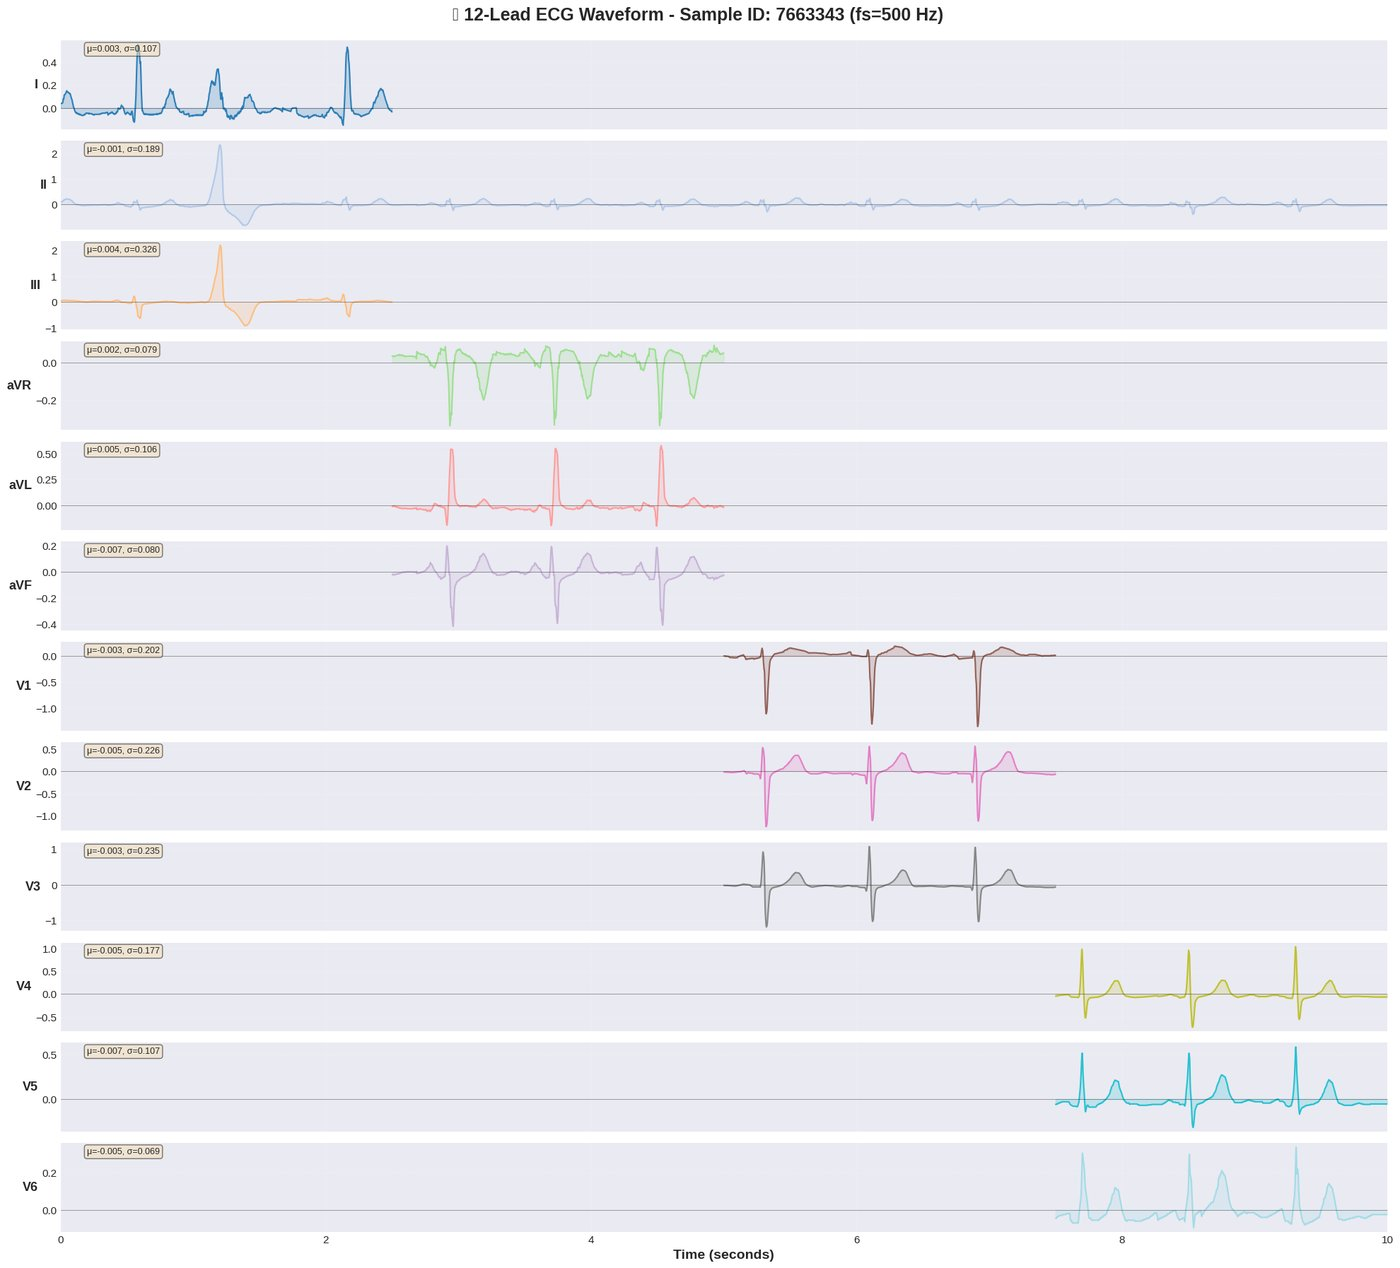

In [ ]:
# Create beautiful 12-lead ECG visualization
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
colors = plt.cm.tab20(np.linspace(0, 1, 12))

fig, axes = plt.subplots(12, 1, figsize=(20, 18), sharex=True)
fig.suptitle(f'🫀 12-Lead ECG Waveform - Sample ID: {sample_id} (fs={sample_fs} Hz)',
             fontsize=18, fontweight='bold', y=0.995)

time_axis = np.arange(len(ecg_data)) / sample_fs

for idx, (ax, lead, color) in enumerate(zip(axes, lead_names, colors)):
    # Plot the waveform
    ax.plot(time_axis, ecg_data[lead], color=color, linewidth=1.5, alpha=0.9)
    ax.fill_between(time_axis, ecg_data[lead], alpha=0.2, color=color)

    # Styling
    ax.set_ylabel(lead, fontsize=13, fontweight='bold', rotation=0, ha='right', va='center')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlim(0, len(ecg_data) / sample_fs)

    # Add horizontal line at zero
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

    # Remove spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Calculate and display basic stats
    mean_val = ecg_data[lead].mean()
    std_val = ecg_data[lead].std()
    ax.text(0.02, 0.95, f'μ={mean_val:.3f}, σ={std_val:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The stored ECG signal and the way it is displayed on a clinical ECG image are not always identical in duration. This comparison shows how the full recording is represented across the different leads.

LEAD DURATION IN CLINICAL ECG IMAGES
📏 Lead II (Rhythm Strip):  10.0 seconds  ← Full cardiac rhythm
📏 Other 11 leads:           2.5 seconds  ← Shorter synchronized segments

💡 Note: In our CSV files, all leads show the full 10-second recording.
   However, in the ECG IMAGES, only the first 2.5 seconds of leads I, III,
   aVR, aVL, aVF, V1-V6 are displayed. Lead II shows all 10 seconds.


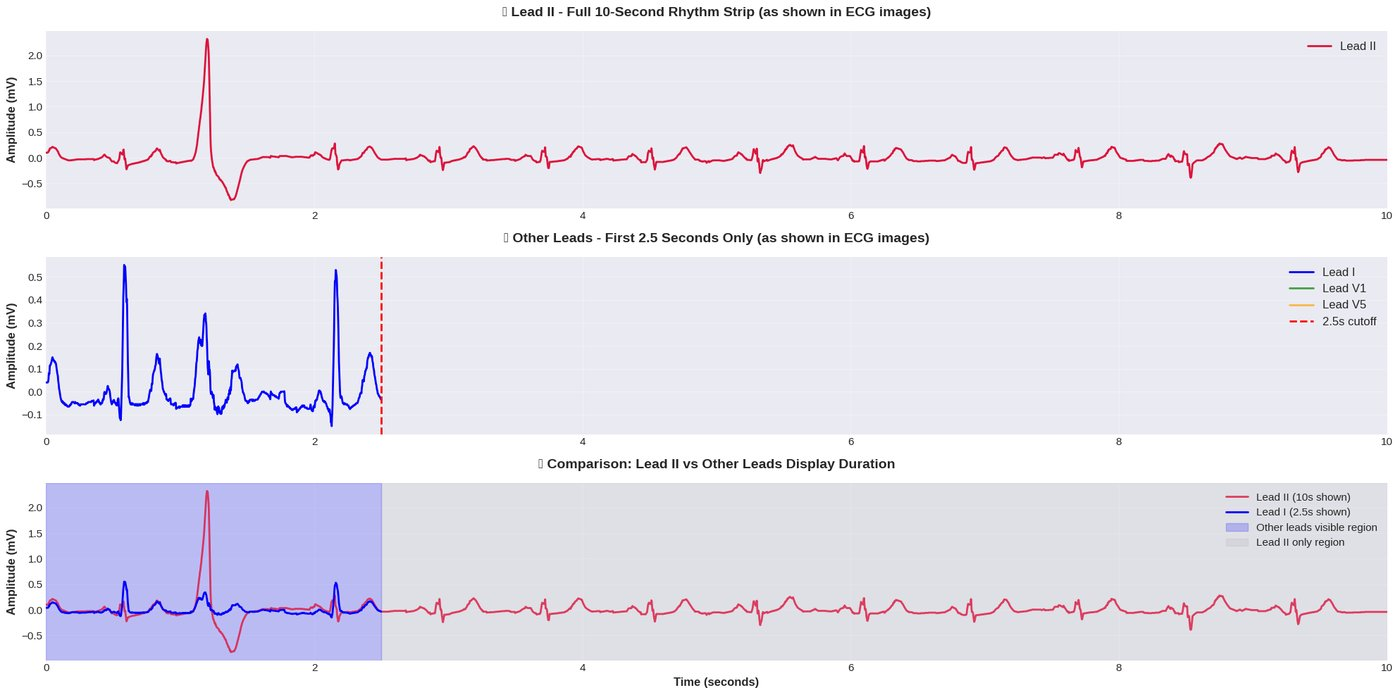

In [ ]:
# Demonstrate lead duration differences
# In clinical ECGs: Lead II is 10 seconds, others are 2.5 seconds

print("=" * 80)
print("LEAD DURATION IN CLINICAL ECG IMAGES")
print("=" * 80)
print("📏 Lead II (Rhythm Strip):  10.0 seconds  ← Full cardiac rhythm")
print("📏 Other 11 leads:           2.5 seconds  ← Shorter synchronized segments")
print("=" * 80)
print("\n💡 Note: In our CSV files, all leads show the full 10-second recording.")
print("   However, in the ECG IMAGES, only the first 2.5 seconds of leads I, III,")
print("   aVR, aVL, aVF, V1-V6 are displayed. Lead II shows all 10 seconds.")
print("=" * 80)

# Visualize this concept
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Full 10-second view
time_full = np.arange(len(ecg_data)) / sample_fs
axes[0].plot(time_full, ecg_data['II'], color='crimson', linewidth=2, label='Lead II')
axes[0].set_title('🔴 Lead II - Full 10-Second Rhythm Strip (as shown in ECG images)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Amplitude (mV)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=12, loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 10)

# First 2.5 seconds - other leads
time_25s = time_full[time_full <= 2.5]
axes[1].plot(time_25s, ecg_data['I'][:len(time_25s)], color='blue', linewidth=2, label='Lead I')
axes[1].plot(time_25s, ecg_data['V1'][:len(time_25s)], color='green', linewidth=2, label='Lead V1', alpha=0.7)
axes[1].plot(time_25s, ecg_data['V5'][:len(time_25s)], color='orange', linewidth=2, label='Lead V5', alpha=0.7)
axes[1].axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='2.5s cutoff')
axes[1].set_title('🔵 Other Leads - First 2.5 Seconds Only (as shown in ECG images)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Amplitude (mV)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 10)

# Comparison
axes[2].plot(time_full, ecg_data['II'], color='crimson', linewidth=2, alpha=0.8, label='Lead II (10s shown)')
axes[2].plot(time_25s, ecg_data['I'][:len(time_25s)], color='blue', linewidth=2, label='Lead I (2.5s shown)')
axes[2].axvspan(0, 2.5, alpha=0.2, color='blue', label='Other leads visible region')
axes[2].axvspan(2.5, 10, alpha=0.1, color='gray', label='Lead II only region')
axes[2].set_title('📊 Comparison: Lead II vs Other Leads Display Duration',
                  fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Amplitude (mV)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=11, loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()

Before analysing the ECG images in detail, I check some basic properties across multiple samples, including image size, aspect ratio, number of channels, file size, and pixel intensity.

IMAGE PROPERTIES ANALYSIS


,id,width,height,aspect_ratio,mode,channels,dtype,file_size_kb,mean_intensity,std_intensity
0,7663343,2200,1700,1.294118,RGBA,4,uint8,366.856445,239.607994,45.353669
1,10140238,2200,1700,1.294118,RGBA,4,uint8,408.936523,239.200248,46.047516
2,11842146,2200,1700,1.294118,RGBA,4,uint8,409.230469,239.034682,46.536881
3,19030958,2200,1700,1.294118,RGBA,4,uint8,356.657227,239.577332,45.589615
4,19585145,2200,1700,1.294118,RGBA,4,uint8,348.642578,239.643441,45.459853
5,31175200,2200,1700,1.294118,RGBA,4,uint8,370.378906,239.482011,45.718284
6,31294838,2200,1700,1.294118,RGBA,4,uint8,394.928711,239.501898,45.444539
7,32650710,2200,1700,1.294118,RGBA,4,uint8,341.341797,239.499343,46.007728
8,35187032,2200,1700,1.294118,RGBA,4,uint8,387.005859,239.074997,46.743099
9,36494663,2200,1700,1.294118,RGBA,4,uint8,370.375977,239.713402,44.828364



STATISTICAL SUMMARY


,id,width,height,aspect_ratio,channels,file_size_kb,mean_intensity,std_intensity
count,2.000000e+01,20.0,20.0,2.000000e+01,20.0,20.000000,20.000000,20.000000
mean,3.929643e+07,2200.0,1700.0,1.294118e+00,4.0,382.104541,239.381392,45.806019
std,1.996030e+07,0.0,0.0,2.278130e-16,0.0,34.379657,0.372255,0.722253
min,7.663343e+06,2200.0,1700.0,1.294118e+00,4.0,341.341797,238.188911,44.666669
25%,2.827769e+07,2200.0,1700.0,1.294118e+00,4.0,360.505371,239.243115,45.400928
50%,3.703720e+07,2200.0,1700.0,1.294118e+00,4.0,370.377441,239.491579,45.738795
75%,5.516125e+07,2200.0,1700.0,1.294118e+00,4.0,400.376465,239.613187,46.065130
max,7.883341e+07,2200.0,1700.0,1.294118e+00,4.0,493.367188,239.862779,47.685354


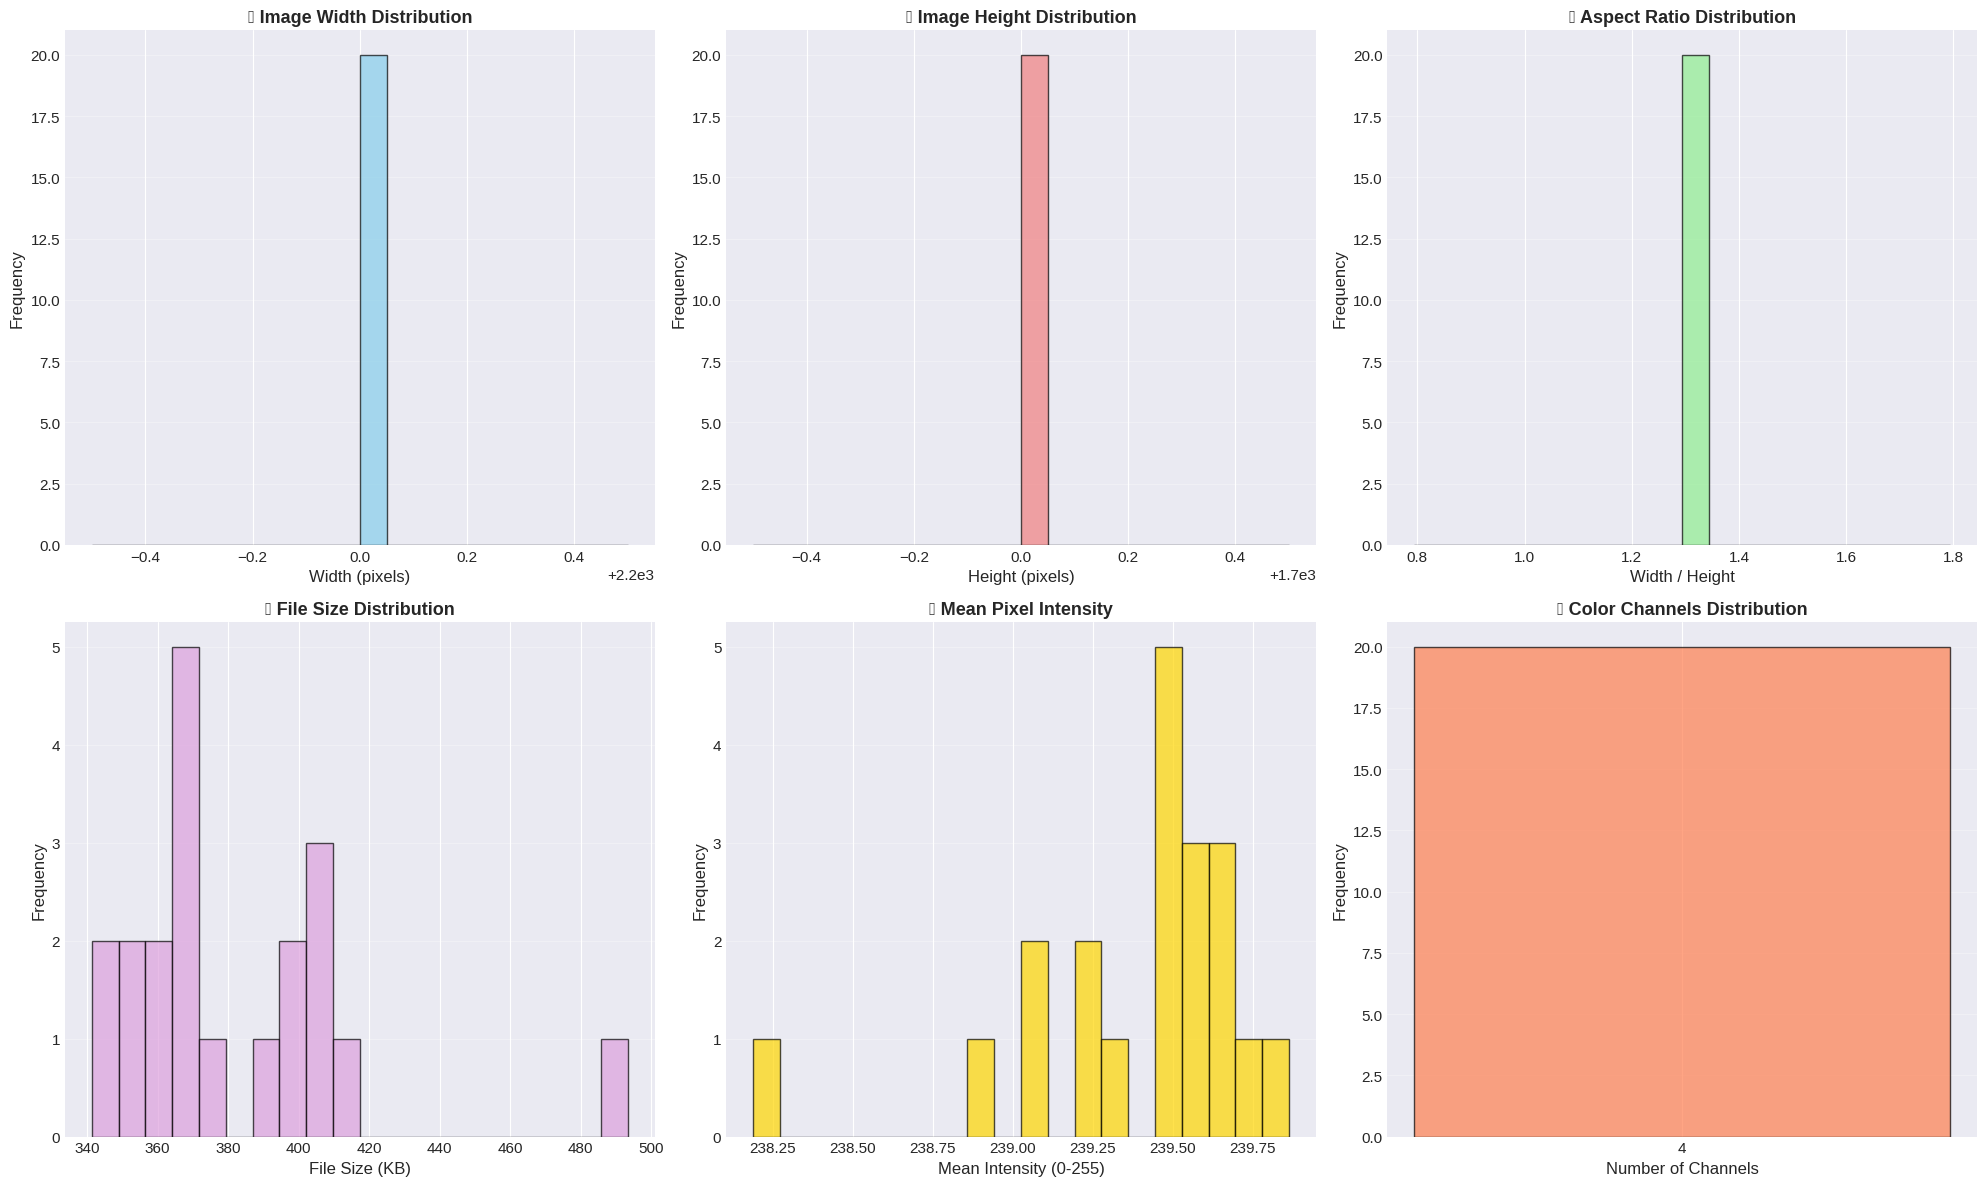


✅ Most common dimensions: 2200 × 1700 pixels
✅ Most common format: RGBA (4 channels)


In [ ]:
# Analyze image properties across multiple samples
sample_ids = train_df['id'].head(20).tolist()
image_properties = []

for sample_id in sample_ids:
    sample_dir = TRAIN_PATH / str(sample_id)
    img_path = sample_dir / f"{sample_id}-0001.png"  # Original image

    if img_path.exists():
        img = Image.open(img_path)
        img_array = np.array(img)

        image_properties.append({
            'id': sample_id,
            'width': img.size[0],
            'height': img.size[1],
            'aspect_ratio': img.size[0] / img.size[1],
            'mode': img.mode,
            'channels': img_array.shape[2] if len(img_array.shape) == 3 else 1,
            'dtype': str(img_array.dtype),
            'file_size_kb': img_path.stat().st_size / 1024,
            'mean_intensity': img_array.mean(),
            'std_intensity': img_array.std()
        })

props_df = pd.DataFrame(image_properties)

print("=" * 80)
print("IMAGE PROPERTIES ANALYSIS")
print("=" * 80)
display(props_df.head(10))

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
display(props_df.describe())

# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Width distribution
axes[0, 0].hist(props_df['width'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('📏 Image Width Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Height distribution
axes[0, 1].hist(props_df['height'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('📏 Image Height Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Aspect ratio
axes[0, 2].hist(props_df['aspect_ratio'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('📐 Aspect Ratio Distribution', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Width / Height')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(axis='y', alpha=0.3)

# File size
axes[1, 0].hist(props_df['file_size_kb'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('💾 File Size Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('File Size (KB)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Mean intensity
axes[1, 1].hist(props_df['mean_intensity'], bins=20, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('💡 Mean Pixel Intensity', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Mean Intensity (0-255)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(axis='y', alpha=0.3)

# Channels
channel_counts = props_df['channels'].value_counts()
axes[1, 2].bar(channel_counts.index.astype(str), channel_counts.values,
               color='coral', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('🎨 Color Channels Distribution', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Number of Channels')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Most common dimensions: {props_df['width'].mode().values[0]:.0f} × {props_df['height'].mode().values[0]:.0f} pixels")
print(f"✅ Most common format: {props_df['mode'].mode().values[0]} ({props_df['channels'].mode().values[0]:.0f} channels)")


Here, I display one original ECG image and its grayscale version. The grayscale view is useful because many image-processing steps for signal extraction work directly with pixel intensity rather than colour.

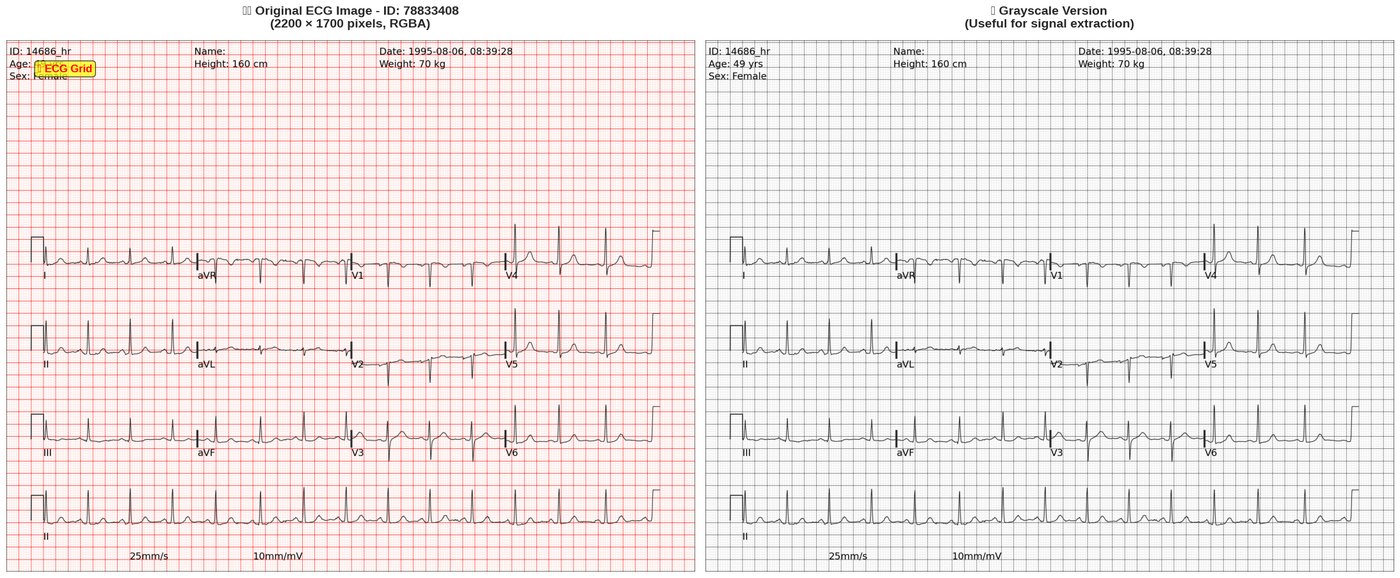

📊 Image shape: (1700, 2200, 4)
📊 Data type: uint8
📊 Value range: [0, 255]
📊 Mean intensity: 239.26


In [ ]:
# Load and display a sample ECG image
img_path = TRAIN_PATH / str(sample_id) / f'{sample_id}-0001.png'
img = Image.open(img_path)
img_array = np.array(img)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Original image
axes[0].imshow(img_array)
axes[0].set_title(f'🖼️ Original ECG Image - ID: {sample_id}\n(2200 × 1700 pixels, {img.mode})',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].axis('off')

# Add annotations
axes[0].text(100, 100, '📊 ECG Grid', fontsize=12, color='red',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontweight='bold')

# Grayscale version
img_gray = cv2.cvtColor(img_array[:,:,:3], cv2.COLOR_RGB2GRAY) if len(img_array.shape) == 3 else img_array
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title(f'⚫ Grayscale Version\n(Useful for signal extraction)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"📊 Image shape: {img_array.shape}")
print(f"📊 Data type: {img_array.dtype}")
print(f"📊 Value range: [{img_array.min()}, {img_array.max()}]")
print(f"📊 Mean intensity: {img_array.mean():.2f}")

---
# Types of images

| Code | Description | Challenge |
|------|-------------|-----------|
| **0001** | Original synthetic image | ✅ Clean baseline |
| **0003** | Printed & scanned (color) | 🔸 Scanning artifacts |
| **0004** | Printed & scanned (B&W) | 🔸 Loss of color info |
| **0005** | Mobile photos (color print) | 🔶 Camera distortion, lighting |
| **0006** | Mobile photos (screen) | 🔶 Moiré patterns, glare |
| **0009** | Stained & soaked prints | 🔴 Physical damage, stains |
| **0010** | Extensively damaged | 🔴 Severe degradation |
| **0011** | Mold (color) | 🔴 Biological damage |
| **0012** | Mold (B&W) | 🔴 Severe quality loss |



The same ECG record is available in different image conditions. Comparing these versions shows how scanning, photography, and severe damage can affect the visibility of the waveform and the overall pixel distribution.

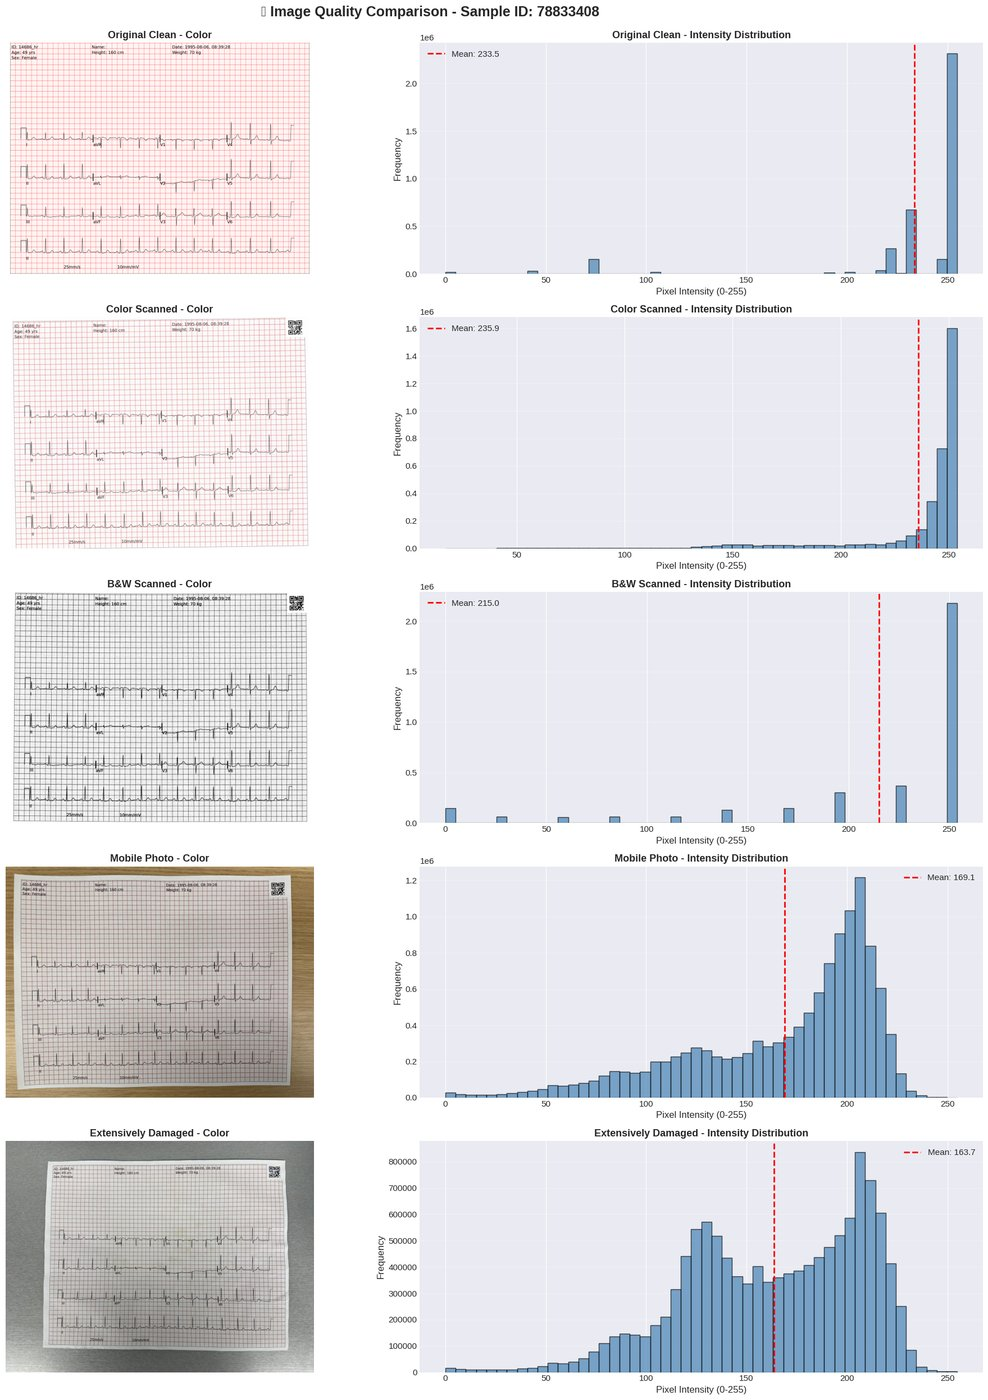

In [ ]:
# Compare different image quality variants
image_variants = {
    '0001': 'Original Clean',
    '0003': 'Color Scanned',
    '0004': 'B&W Scanned',
    '0005': 'Mobile Photo',
    '0010': 'Extensively Damaged'
}

fig, axes = plt.subplots(len(image_variants), 2, figsize=(20, 5*len(image_variants)))
fig.suptitle(f'🔍 Image Quality Comparison - Sample ID: {sample_id}',
             fontsize=18, fontweight='bold', y=0.995)

for idx, (variant_code, variant_name) in enumerate(image_variants.items()):
    img_path = TRAIN_PATH / str(sample_id) / f'{sample_id}-{variant_code}.png'

    if img_path.exists():
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # RGB version
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f'{variant_name} - Color', fontsize=13, fontweight='bold')
        axes[idx, 0].axis('off')

        # Intensity histogram
        axes[idx, 1].hist(img_gray.flatten(), bins=50, color='steelblue',
                         edgecolor='black', alpha=0.7)
        axes[idx, 1].set_title(f'{variant_name} - Intensity Distribution',
                              fontsize=13, fontweight='bold')
        axes[idx, 1].set_xlabel('Pixel Intensity (0-255)')
        axes[idx, 1].set_ylabel('Frequency')
        axes[idx, 1].grid(axis='y', alpha=0.3)

        # Add statistics
        mean_int = img_gray.mean()
        std_int = img_gray.std()
        axes[idx, 1].axvline(mean_int, color='red', linestyle='--', linewidth=2,
                            label=f'Mean: {mean_int:.1f}')
        axes[idx, 1].legend()
    else:
        axes[idx, 0].text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=14)
        axes[idx, 0].axis('off')
        axes[idx, 1].text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=14)
        axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

A closer look at the same region makes the effect of image degradation easier to observe. This helps compare how clearly the ECG trace and grid remain visible across different image conditions.

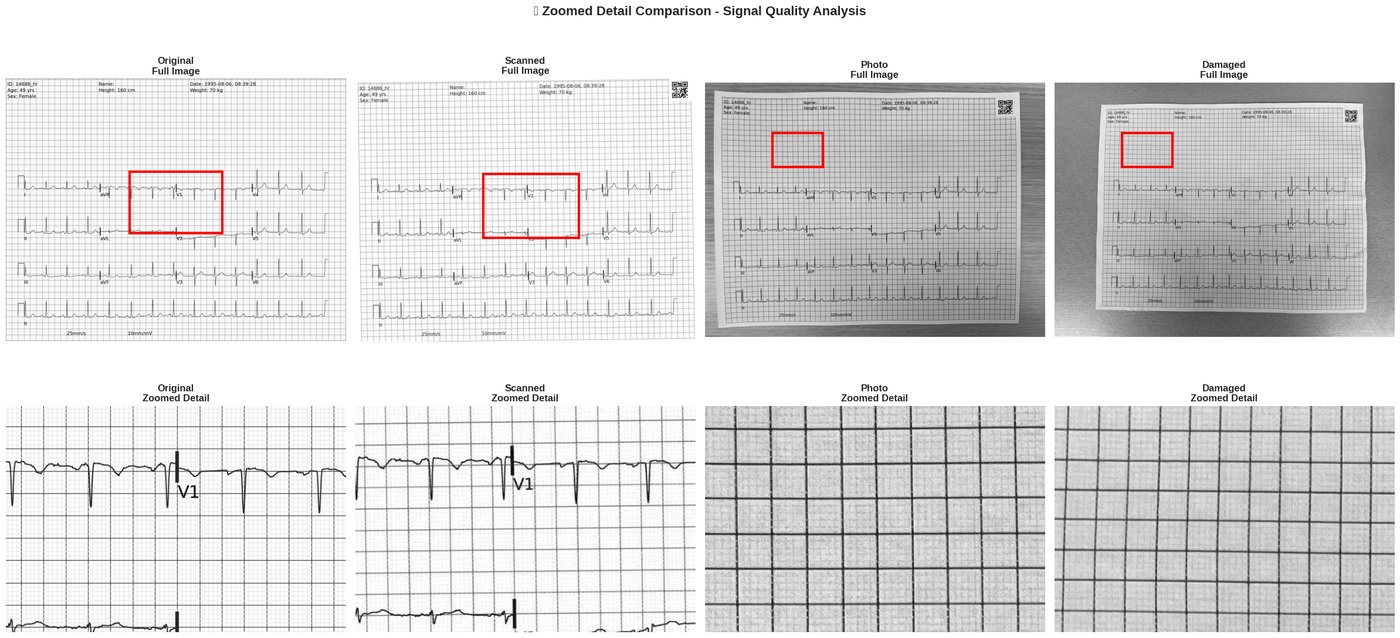

In [ ]:
# Zoom into a specific region to see degradation details
crop_height = 400
crop_width = 600
start_y = 600
start_x = 800

variants_to_compare = ['0001', '0003', '0005', '0010']
variant_names_short = ['Original', 'Scanned', 'Photo', 'Damaged']

fig, axes = plt.subplots(2, len(variants_to_compare), figsize=(24, 12))
fig.suptitle('🔬 Zoomed Detail Comparison - Signal Quality Analysis',
             fontsize=16, fontweight='bold', y=0.995)

for idx, (variant_code, variant_name) in enumerate(zip(variants_to_compare, variant_names_short)):
    img_path = TRAIN_PATH / str(sample_id) / f'{sample_id}-{variant_code}.png'

    if img_path.exists():
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Crop the region
        cropped_rgb = img_rgb[start_y:start_y+crop_height, start_x:start_x+crop_width]
        cropped_gray = img_gray[start_y:start_y+crop_height, start_x:start_x+crop_width]

        # Show full image with crop location
        axes[0, idx].imshow(img_gray, cmap='gray')
        rect = plt.Rectangle((start_x, start_y), crop_width, crop_height,
                            fill=False, edgecolor='red', linewidth=3)
        axes[0, idx].add_patch(rect)
        axes[0, idx].set_title(f'{variant_name}\nFull Image', fontsize=12, fontweight='bold')
        axes[0, idx].axis('off')

        # Show cropped detail
        axes[1, idx].imshow(cropped_gray, cmap='gray')
        axes[1, idx].set_title(f'{variant_name}\nZoomed Detail', fontsize=12, fontweight='bold')
        axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

---

- **Horizontal axis**: Time (standard: 1mm = 0.04 seconds)
- **Vertical axis**: Voltage (standard: 1mm = 0.1 mV)



The ECG paper grid provides useful positional information for signal recovery. In this step, edge detection and line detection are used to examine the horizontal and vertical structure present in the image.

GRID STRUCTURE ANALYSIS
✅ Total lines detected: 1812
📊 Horizontal lines: 1812 (shown in RED)
📊 Vertical lines: 0 (shown in GREEN)


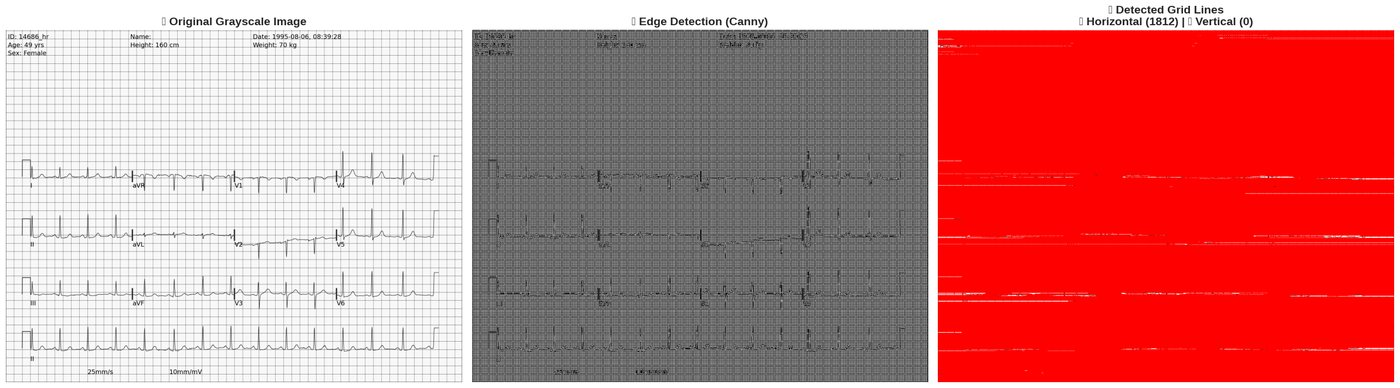

In [ ]:
# Detect and visualize grid structure
img_path = TRAIN_PATH / str(sample_id) / f'{sample_id}-0001.png'
img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(img_gray, 30, 100)

# Detect lines using Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=100, maxLineGap=10)

# Separate horizontal and vertical lines
horizontal_lines = []
vertical_lines = []

img_with_lines = img_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi)

        if angle < 10 or angle > 170:  # Horizontal
            horizontal_lines.append(line)
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (255, 0, 0), 2)
        elif 80 < angle < 100:  # Vertical
            vertical_lines.append(line)
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

print("=" * 80)
print("GRID STRUCTURE ANALYSIS")
print("=" * 80)
print(f"✅ Total lines detected: {len(lines) if lines is not None else 0}")
print(f"📊 Horizontal lines: {len(horizontal_lines)} (shown in RED)")
print(f"📊 Vertical lines: {len(vertical_lines)} (shown in GREEN)")
print("=" * 80)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('📄 Original Grayscale Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('🔍 Edge Detection (Canny)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_with_lines)
axes[2].set_title(f'📐 Detected Grid Lines\n🔴 Horizontal ({len(horizontal_lines)}) | 🟢 Vertical ({len(vertical_lines)})',
                 fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

I also analyse the image by summing pixel values across rows and columns. These projections can highlight the overall layout of the ECG and show where strong horizontal or vertical structures are present.

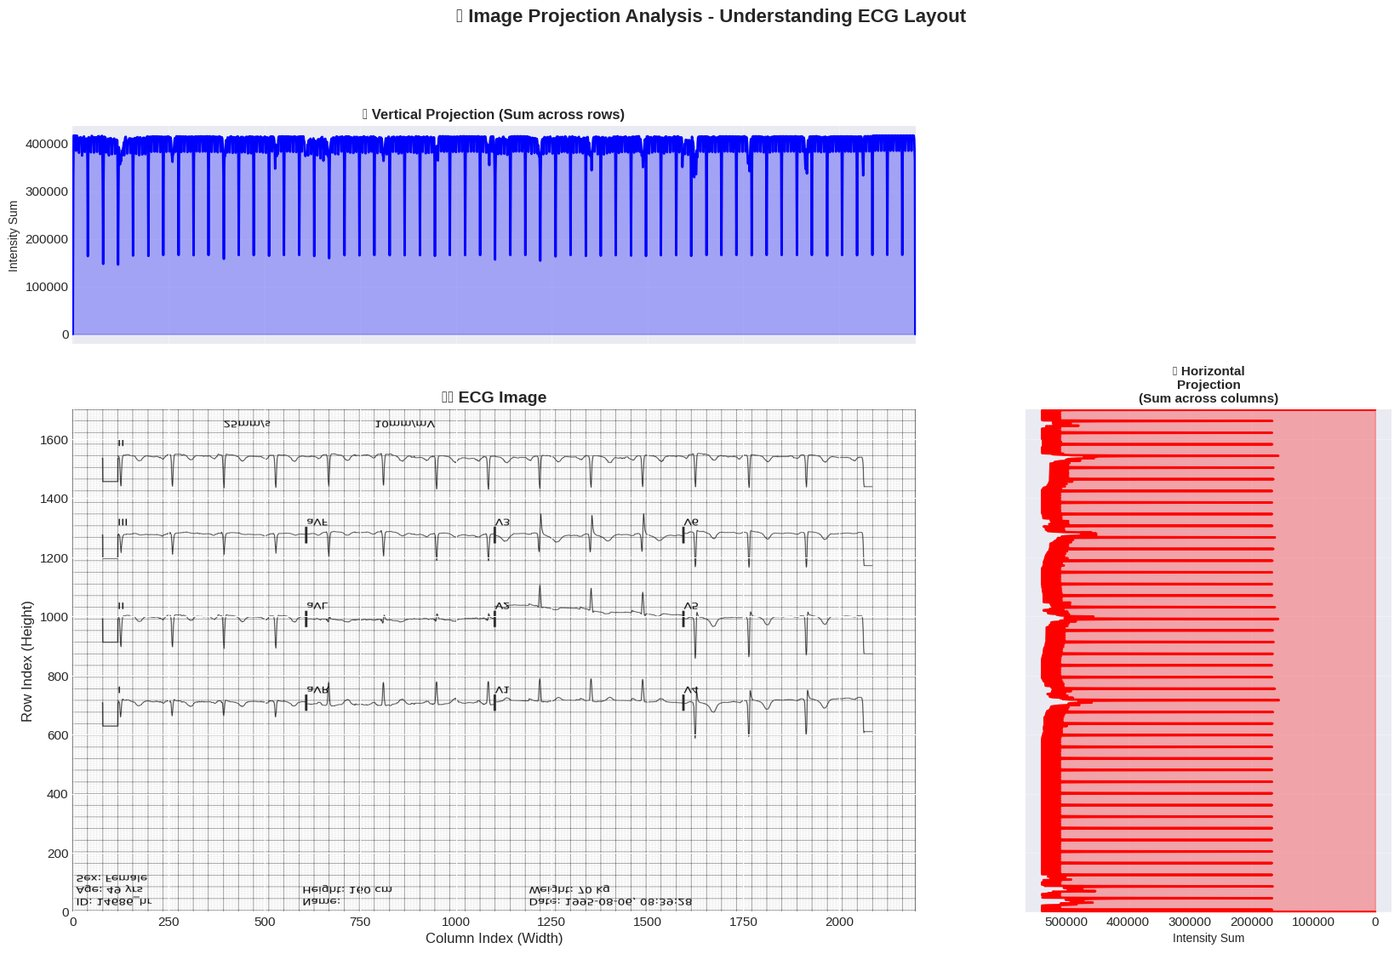


💡 Interpretation:
   - Vertical projection shows the overall horizontal distribution of signals
   - Horizontal projection reveals the vertical layout (rows of leads)
   - Peaks and valleys help identify lead boundaries and grid structure


In [ ]:
# Analyze horizontal and vertical projections to understand structure
horizontal_proj = np.sum(img_gray, axis=1)
vertical_proj = np.sum(img_gray, axis=0)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main image
ax_main = fig.add_subplot(gs[1:, :2])
ax_main.imshow(img_gray, cmap='gray', aspect='auto')
ax_main.set_title('🖼️ ECG Image', fontsize=14, fontweight='bold')
ax_main.set_xlabel('Column Index (Width)', fontsize=12)
ax_main.set_ylabel('Row Index (Height)', fontsize=12)

# Horizontal projection (top)
ax_top = fig.add_subplot(gs[0, :2], sharex=ax_main)
ax_top.plot(vertical_proj, color='blue', linewidth=2)
ax_top.fill_between(range(len(vertical_proj)), vertical_proj, alpha=0.3, color='blue')
ax_top.set_title('📊 Vertical Projection (Sum across rows)', fontsize=12, fontweight='bold')
ax_top.set_ylabel('Intensity Sum', fontsize=10)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# Vertical projection (right)
ax_right = fig.add_subplot(gs[1:, 2], sharey=ax_main)
ax_right.plot(horizontal_proj, range(len(horizontal_proj)), color='red', linewidth=2)
ax_right.fill_betweenx(range(len(horizontal_proj)), horizontal_proj, alpha=0.3, color='red')
ax_right.set_title('📊 Horizontal\nProjection\n(Sum across columns)', fontsize=11, fontweight='bold')
ax_right.set_xlabel('Intensity Sum', fontsize=10)
ax_right.grid(True, alpha=0.3)
ax_right.tick_params(labelleft=False)
ax_right.invert_xaxis()
ax_right.invert_yaxis()

plt.suptitle('📐 Image Projection Analysis - Understanding ECG Layout',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n💡 Interpretation:")
print("   - Vertical projection shows the overall horizontal distribution of signals")
print("   - Horizontal projection reveals the vertical layout (rows of leads)")
print("   - Peaks and valleys help identify lead boundaries and grid structure")

To compare the original ECG leads numerically, I calculate basic statistics such as mean, standard deviation, range, median, and RMS. These values give a simple summary of the amplitude and variability of each lead.

SIGNAL STATISTICS BY LEAD


,Lead,Mean (mV),Std Dev (mV),Min (mV),Max (mV),Range (mV),Median (mV),RMS
0,I,nan,nan,nan,nan,nan,nan,nan
1,II,-0.001107,0.188544,-0.827000,2.325000,3.152000,-0.025000,0.188548
2,III,nan,nan,nan,nan,nan,nan,nan
3,aVR,nan,nan,nan,nan,nan,nan,nan
4,aVL,nan,nan,nan,nan,nan,nan,nan
5,aVF,nan,nan,nan,nan,nan,nan,nan
6,V1,nan,nan,nan,nan,nan,nan,nan
7,V2,nan,nan,nan,nan,nan,nan,nan
8,V3,nan,nan,nan,nan,nan,nan,nan
9,V4,nan,nan,nan,nan,nan,nan,nan


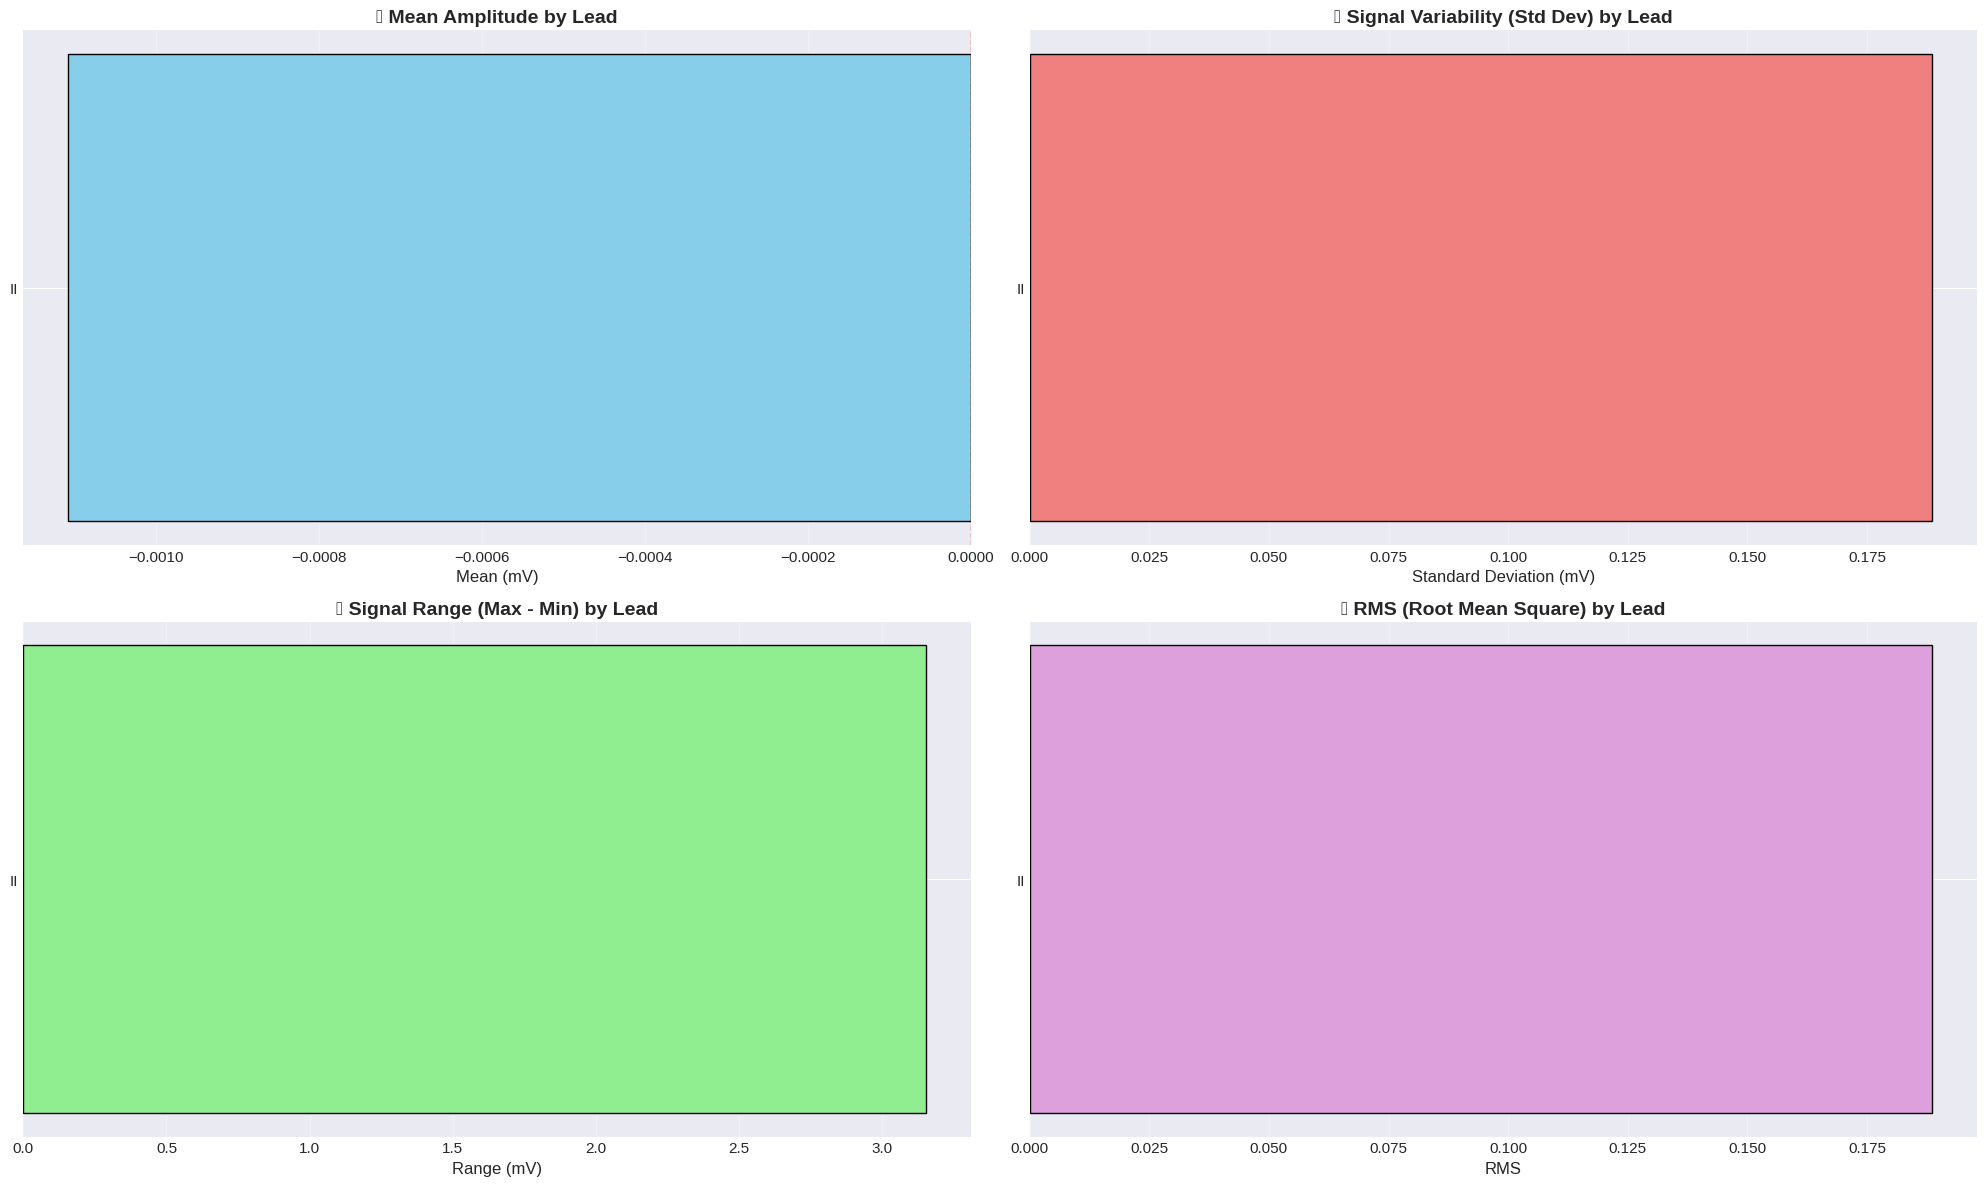

In [ ]:
# Comprehensive signal statistics
lead_stats = []

for lead in lead_names:
    lead_data = ecg_data[lead].values

    lead_stats.append({
        'Lead': lead,
        'Mean (mV)': lead_data.mean(),
        'Std Dev (mV)': lead_data.std(),
        'Min (mV)': lead_data.min(),
        'Max (mV)': lead_data.max(),
        'Range (mV)': lead_data.max() - lead_data.min(),
        'Median (mV)': np.median(lead_data),
        'RMS': np.sqrt(np.mean(lead_data**2))
    })

stats_df = pd.DataFrame(lead_stats)

print("=" * 100)
print("SIGNAL STATISTICS BY LEAD")
print("=" * 100)
display(stats_df.style.background_gradient(cmap='RdYlGn', subset=['Range (mV)', 'Std Dev (mV)']))

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Mean values
axes[0, 0].barh(stats_df['Lead'], stats_df['Mean (mV)'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('📊 Mean Amplitude by Lead', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Mean (mV)', fontsize=12)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].grid(axis='x', alpha=0.3)

# Standard deviation
axes[0, 1].barh(stats_df['Lead'], stats_df['Std Dev (mV)'], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('📊 Signal Variability (Std Dev) by Lead', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Standard Deviation (mV)', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)

# Range
axes[1, 0].barh(stats_df['Lead'], stats_df['Range (mV)'], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('📊 Signal Range (Max - Min) by Lead', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Range (mV)', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)

# RMS
axes[1, 1].barh(stats_df['Lead'], stats_df['RMS'], color='plum', edgecolor='black')
axes[1, 1].set_title('📊 RMS (Root Mean Square) by Lead', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('RMS', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Different ECG leads are related because they observe the same cardiac activity from different directions. The correlation matrix helps visualise which leads have similar or opposite waveform patterns.

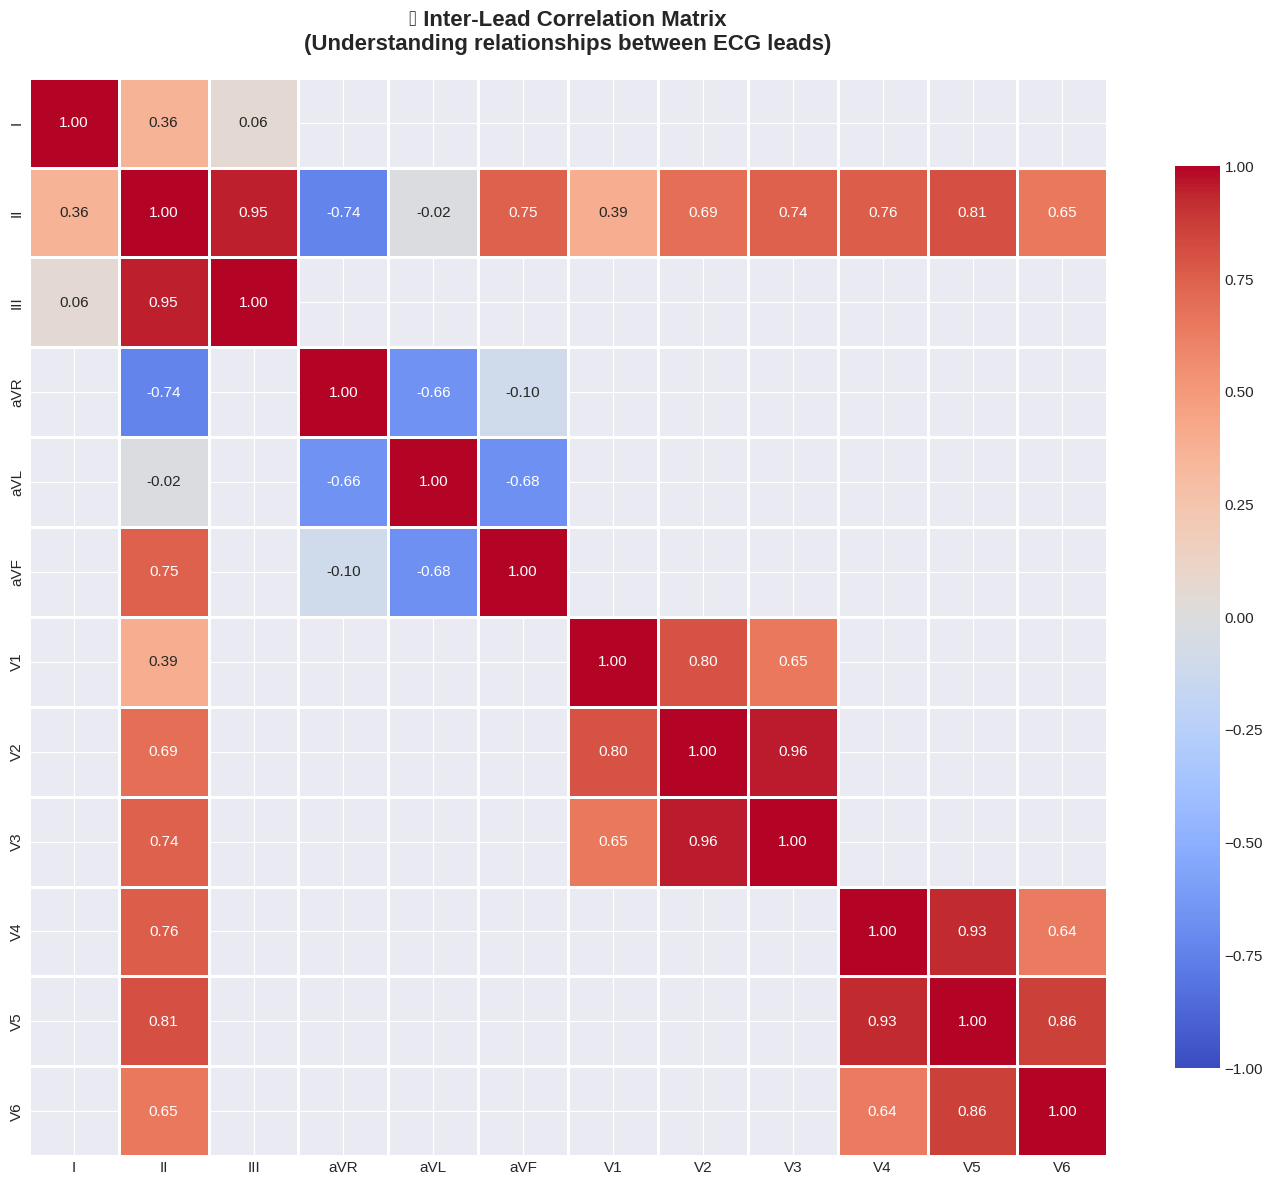


💡 Key Observations:
   - Some leads show strong positive correlations (similar waveforms)
   - Some leads show negative correlations (inverted waveforms)
   - These relationships are based on cardiac electrical vectors
   - aVR typically shows inverse patterns compared to other leads


In [ ]:
# Lead correlation analysis
correlation_matrix = ecg_data[lead_names].corr()

fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('🔗 Inter-Lead Correlation Matrix\n(Understanding relationships between ECG leads)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   - Some leads show strong positive correlations (similar waveforms)")
print("   - Some leads show negative correlations (inverted waveforms)")
print("   - These relationships are based on cardiac electrical vectors")
print("   - aVR typically shows inverse patterns compared to other leads")

In addition to the time-domain waveform, I examine the frequency content of a few representative leads using the Fourier transform. This gives another view of how the ECG signal is distributed across different frequencies.

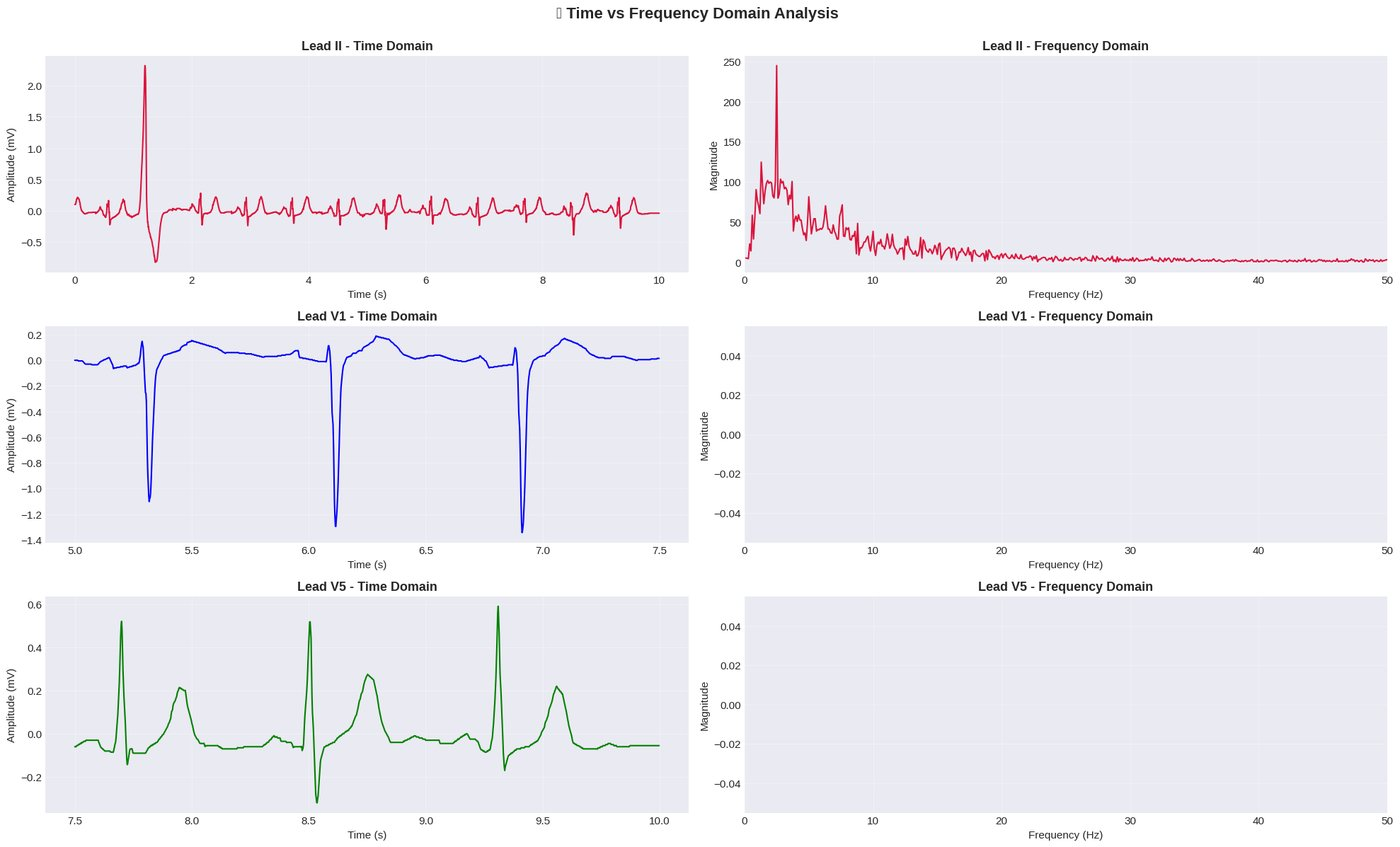


💡 Frequency Domain Insights:
   - ECG signals contain frequencies mainly < 50 Hz
   - Dominant frequencies correspond to heart rate (1-3 Hz)
   - Higher frequencies capture fine details of QRS complex


In [ ]:
# Analyze frequency content of ECG signals
from scipy.fft import fft, fftfreq

# Select a few representative leads
selected_leads = ['II', 'V1', 'V5']
colors_freq = ['crimson', 'blue', 'green']

fig, axes = plt.subplots(len(selected_leads), 2, figsize=(20, 12))
fig.suptitle('🌊 Time vs Frequency Domain Analysis', fontsize=16, fontweight='bold', y=0.995)

for idx, (lead, color) in enumerate(zip(selected_leads, colors_freq)):
    signal_data = ecg_data[lead].values
    n = len(signal_data)

    # Time domain
    time = np.arange(n) / sample_fs
    axes[idx, 0].plot(time, signal_data, color=color, linewidth=1.5)
    axes[idx, 0].set_title(f'Lead {lead} - Time Domain', fontsize=13, fontweight='bold')
    axes[idx, 0].set_xlabel('Time (s)', fontsize=11)
    axes[idx, 0].set_ylabel('Amplitude (mV)', fontsize=11)
    axes[idx, 0].grid(True, alpha=0.3)

    # Frequency domain (FFT)
    yf = fft(signal_data)
    xf = fftfreq(n, 1/sample_fs)

    # Only positive frequencies
    positive_freqs = xf > 0
    axes[idx, 1].plot(xf[positive_freqs], np.abs(yf[positive_freqs]), color=color, linewidth=1.5)
    axes[idx, 1].set_title(f'Lead {lead} - Frequency Domain', fontsize=13, fontweight='bold')
    axes[idx, 1].set_xlabel('Frequency (Hz)', fontsize=11)
    axes[idx, 1].set_ylabel('Magnitude', fontsize=11)
    axes[idx, 1].set_xlim(0, 50)  # Focus on physiologically relevant frequencies
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Frequency Domain Insights:")
print("   - ECG signals contain frequencies mainly < 50 Hz")
print("   - Dominant frequencies correspond to heart rate (1-3 Hz)")
print("   - Higher frequencies capture fine details of QRS complex")

The test metadata determines what needs to be reconstructed for each ECG image. Here, I summarise the number of leads, sampling frequencies, and the number of signal values required in the final predictions.

TEST DATA STRUCTURE

📊 Total unique test IDs: 2
📊 Total predictions required: 24 rows

        id  num_leads   fs  total_rows_to_predict
1053922973         12 1000                  37500
2352854581         12 1000                  37500

PREDICTIONS REQUIRED PER LEAD

        min    max     mean  count
lead                              
I      2500   2500   2500.0      2
II    10000  10000  10000.0      2
III    2500   2500   2500.0      2
V1     2500   2500   2500.0      2
V2     2500   2500   2500.0      2
V3     2500   2500   2500.0      2
V4     2500   2500   2500.0      2
V5     2500   2500   2500.0      2
V6     2500   2500   2500.0      2
aVF    2500   2500   2500.0      2
aVL    2500   2500   2500.0      2
aVR    2500   2500   2500.0      2


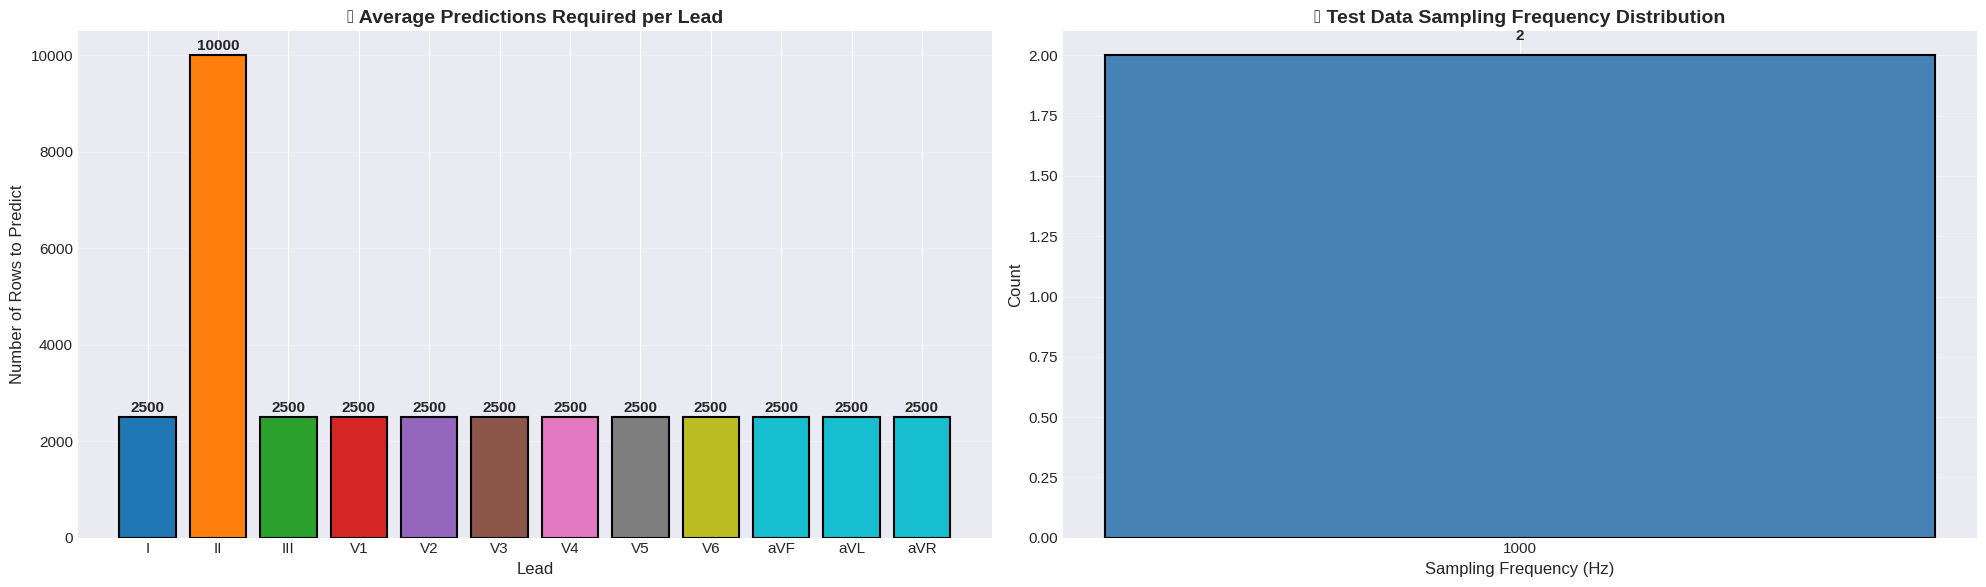


💡 Key Points:
   - Lead II requires ~2.5× more predictions (10s vs 2.5s)
   - All 12 leads must be predicted for each test image
   - Output format: {base_id}_{row_id}_{lead}


In [ ]:
# Analyze test data structure
print("=" * 80)
print("TEST DATA STRUCTURE")
print("=" * 80)

test_summary = test_df.groupby('id').agg({
    'lead': 'count',
    'fs': 'first',
    'number_of_rows': 'sum'
}).reset_index()
test_summary.columns = ['id', 'num_leads', 'fs', 'total_rows_to_predict']

print(f"\n📊 Total unique test IDs: {len(test_summary)}")
print(f"📊 Total predictions required: {test_df.shape[0]:,} rows")
print(f"\n{test_summary.to_string(index=False)}")

# Analyze predictions per lead
lead_predictions = test_df.groupby('lead')['number_of_rows'].agg(['min', 'max', 'mean', 'count'])
print("\n" + "=" * 80)
print("PREDICTIONS REQUIRED PER LEAD")
print("=" * 80)
print(f"\n{lead_predictions.to_string()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Predictions per lead
lead_counts = test_df.groupby('lead')['number_of_rows'].mean()
colors_bar = plt.cm.tab10(np.arange(len(lead_counts)))

axes[0].bar(lead_counts.index, lead_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_title('📊 Average Predictions Required per Lead', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lead', fontsize=12)
axes[0].set_ylabel('Number of Rows to Predict', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=0)

# Add value labels
for i, (lead, count) in enumerate(zip(lead_counts.index, lead_counts.values)):
    axes[0].text(i, count + 50, f'{count:.0f}', ha='center', va='bottom', fontweight='bold')

# Sampling frequency distribution in test
test_fs_dist = test_summary['fs'].value_counts().sort_index()
axes[1].bar(test_fs_dist.index.astype(str), test_fs_dist.values,
           color='steelblue', edgecolor='black', linewidth=1.5)
axes[1].set_title('📊 Test Data Sampling Frequency Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sampling Frequency (Hz)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (fs, count) in enumerate(zip(test_fs_dist.index, test_fs_dist.values)):
    axes[1].text(i, count + 0.05, f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key Points:")
print("   - Lead II requires ~2.5× more predictions (10s vs 2.5s)")
print("   - All 12 leads must be predicted for each test image")
print("   - Output format: {base_id}_{row_id}_{lead}")


Finally, I inspect one test image in both its original and grayscale forms. This provides a direct view of the type of image from which the ECG signal has to be recovered.

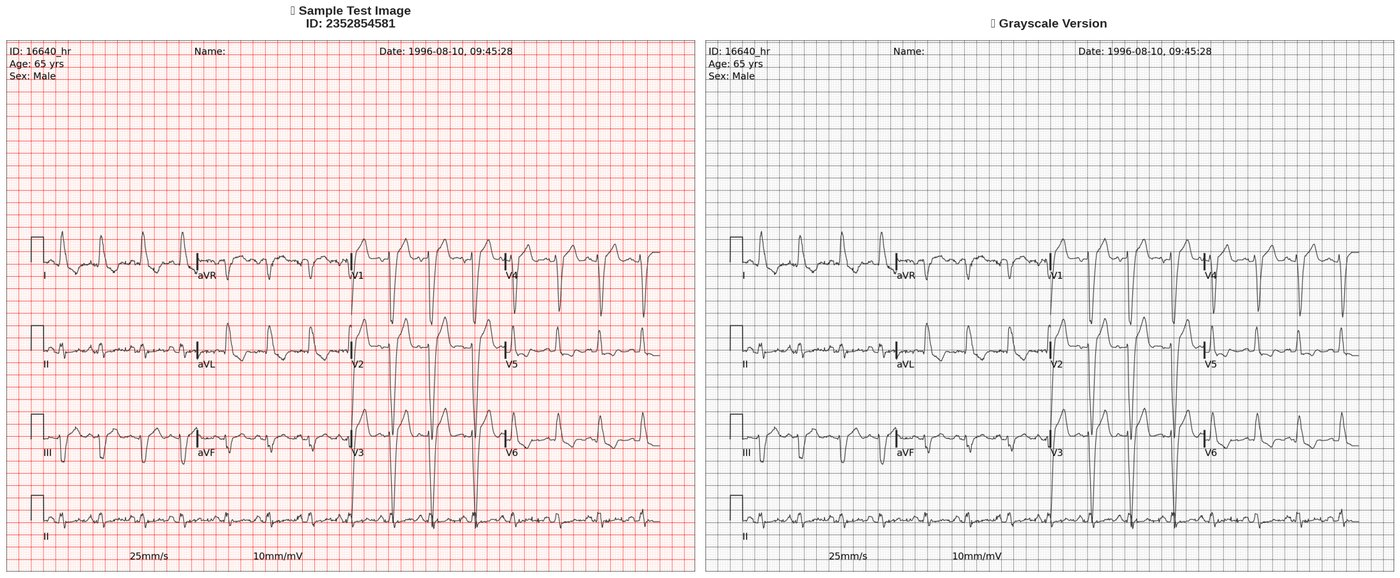

📊 Test Image ID: 2352854581
📊 Image Shape: (1700, 2200, 4)
📊 Image Size: (2200, 1700)


In [ ]:
# Display a sample test image
test_image_files = list(TEST_PATH.glob('*.png'))
if test_image_files:
    sample_test_img_path = test_image_files[0]
    sample_test_id = sample_test_img_path.stem

    test_img = Image.open(sample_test_img_path)
    test_img_array = np.array(test_img)

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    axes[0].imshow(test_img_array)
    axes[0].set_title(f'🎯 Sample Test Image\nID: {sample_test_id}',
                     fontsize=14, fontweight='bold', pad=15)
    axes[0].axis('off')

    # Grayscale
    if len(test_img_array.shape) == 3:
        test_img_gray = cv2.cvtColor(test_img_array[:,:,:3], cv2.COLOR_RGB2GRAY)
    else:
        test_img_gray = test_img_array

    axes[1].imshow(test_img_gray, cmap='gray')
    axes[1].set_title(f'⚫ Grayscale Version', fontsize=14, fontweight='bold', pad=15)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"📊 Test Image ID: {sample_test_id}")
    print(f"📊 Image Shape: {test_img_array.shape}")
    print(f"📊 Image Size: {test_img.size}")
else:
    print("⚠️ No test images found in the test directory")

The last step brings together the main characteristics observed throughout the analysis, including the dataset size, ECG structure, sampling frequencies, image variants, and prediction requirements.

In [ ]:
# Final comprehensive summary
print("=" * 100)
print("🎯 COMPREHENSIVE DATASET SUMMARY")
print("=" * 100)

summary_stats = {
    'Category': [
        'Training Samples',
        'Test Images',
        'Total Test Predictions',
        'ECG Leads',
        'Sampling Frequencies',
        'Image Dimensions (typical)',
        'Image Variants per Sample',
        'Lead II Duration',
        'Other Leads Duration',
        'Evaluation Metric'
    ],
    'Value': [
        f'{len(train_df):,}',
        f'{len(test_df["id"].unique()):,}',
        f'{len(test_df):,}',
        '12 (I, II, III, aVR, aVL, aVF, V1-V6)',
        '250, 500, 1000 Hz',
        '2200 × 1700 pixels',
        '9 quality variants (0001-0012)',
        '10 seconds (full rhythm)',
        '2.5 seconds',
        'Modified SNR (dB)'
    ]
}

summary_df = pd.DataFrame(summary_stats)
display(summary_df.style.set_properties(**{
    'text-align': 'left',
    'font-size': '12pt',
}).hide(axis='index'))



🎯 COMPREHENSIVE DATASET SUMMARY


Category,Value
Training Samples,977
Test Images,2
Total Test Predictions,24
ECG Leads,"12 (I, II, III, aVR, aVL, aVF, V1-V6)"
Sampling Frequencies,"250, 500, 1000 Hz"
Image Dimensions (typical),2200 × 1700 pixels
Image Variants per Sample,9 quality variants (0001-0012)
Lead II Duration,10 seconds (full rhythm)
Other Leads Duration,2.5 seconds
Evaluation Metric,Modified SNR (dB)
